##### Implementing: [Playlist](https://www.youtube.com/playlist?list=PLa14hsXP1CHRya4B4sK234p9YBB-Tgbqm)

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import time

### Loading and making the datset compatible with everything

In [2]:
dataset_train = pd.read_csv('leaf-classification/train.csv')
dataset_test = pd.read_csv('leaf-classification/test.csv')

dataset_train.shape, dataset_test.shape

((990, 194), (594, 193))

In [3]:
dataset_train.sample(5)

,id,species,margin1,margin2,margin3,margin4,margin5,margin6,margin7,margin8,...,texture55,texture56,texture57,texture58,texture59,texture60,texture61,texture62,texture63,texture64
336,552,Cotinus_Coggygria,0.046875,0.115230,0.021484,0.000000,0.000000,0.132810,0.023438,0.005859,...,0.019531,0.0,0.013672,0.000000,0.012695,0.000000,0.000000,0.000977,0.009766,0.000000
563,898,Quercus_Dolicholepis,0.029297,0.050781,0.029297,0.005859,0.005859,0.095703,0.029297,0.000000,...,0.000000,0.0,0.000000,0.060547,0.001953,0.060547,0.000000,0.375980,0.006836,0.000000
16,26,Phildelphus,0.009766,0.062500,0.033203,0.029297,0.011719,0.044922,0.005859,0.000000,...,0.000000,0.0,0.004883,0.000000,0.068359,0.000000,0.000000,0.000000,0.036133,0.000977
826,1326,Quercus_Phillyraeoides,0.019531,0.015625,0.031250,0.041016,0.021484,0.041016,0.042969,0.000000,...,0.000000,0.0,0.002930,0.000977,0.019531,0.000000,0.000977,0.005859,0.041016,0.010742
383,631,Quercus_x_Hispanica,0.007812,0.001953,0.027344,0.009766,0.007812,0.003906,0.035156,0.005859,...,0.000000,0.0,0.000000,0.009766,0.028320,0.004883,0.000000,0.030273,0.015625,0.000000


In [4]:
X = dataset_train.drop(columns=['id', 'species']).values
y = dataset_train['species'].values
X_test = dataset_test.drop(columns=['id']).values
X.shape, y.shape, X_test.shape

((990, 192), (990,), (594, 192))

In [5]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

X_train, X_valid, y_train, y_valid = train_test_split(X, y_encoded, test_size=0.2, random_state=123)

X_train.shape, y_train.shape, X_valid.shape, y_valid.shape

((792, 192), (792,), (198, 192), (198,))

### Borrowing from Simple Decision Tree, but vectorizing it

In [6]:
class Node:
    def __init__(self, feature_idx=None, threshold=None, info_gain=None, left=None, right=None, value=None):
        # A Node can either be a Decision Node or a Pure Node
        
        # Decision Node: Splitting data based on a feature with some threshold
        self.feature_idx = feature_idx
        self.threshold = threshold
        self.info_gain = info_gain
        self.left = left
        self.right = right

        # Leaf Node: Pure, hence only has which class it belongs to
        self.value = value

In [129]:
class DecisionTree:
    def __init__(self, min_samples_split=2, max_depth=2):
        # Min Samples for splitting to occur
        self.min_samples_split=min_samples_split
        # Max depth for base case and preventing overfitting
        self.max_depth = max_depth

    def build_tree(self, X, y, curr_depth=0):
        n_samples, n_features = X.shape

        # For a Decision Node
        if n_samples >= self.min_samples_split and curr_depth < self.max_depth:
            best_split = self.best_split(X, y, n_features)

            # Ensuring not a pure node, and no feature exhaustion
            if best_split["info_gain"] > 0:
                left_node = self.build_tree(best_split["left_X"], best_split["left_y"], curr_depth + 1)
                right_node = self.build_tree(best_split["right_X"], best_split["right_y"], curr_depth + 1)

                return Node(best_split["feature_idx"], best_split["threshold"], best_split["info_gain"], left_node, right_node)

        # Returning a Pure Node with Majority class
        classes, counts = np.unique(y, return_counts=True)
        leaf_value = classes[np.argmax(counts)]
        return Node(value=leaf_value)

    def best_split(self, X, y, n_feature):
        b_split = {
            "feature_idx": None,
            "threshold": None,
            "info_gain": -1,
            "left_X": None,
            "left_y": None,
            "right_X": None,
            "right_y": None
        }

        # This remains same, hence shouldn't calc it again and again
        y_entropy = self.entropy(y)

        # y one hot for later finding the count of classes
        y_one_hot = y.reshape(-1, 1) == np.unique(y) # (rows, 1) == (classes) -> (rows, classes)

        # Trying every possible feature x with every possible threshold to break and find resulting purity
        # X: (rows, features), y: (rows); You first want: Every possible mask for every threshold and every feature
        thresholds = np.unique(X, axis=0)            # (thresholds, features)
        left_mask = X[:, :, None] <= thresholds.T    # (rows, features, 1) <= (features, thresholds) = (rows, features, thresholds)

        # Finding Entropy of the left and right mask:   
        # p_i for a class i = instances of i in the subset / number of classes in the subset
        # Entropy = sum_over_classes(-p_i * log(p_i))
        count_left = left_mask.T @ y_one_hot                # (thresholds, features, rows) @ (rows, classes) = (thresholds, features, classes)
        count_right = y_one_hot.sum(axis=0) - count_left    # (classes) - (thresholds, features, classes) = (thresholds, features, classes)
        total_left = count_left.sum(axis=2, keepdims=True)  # (thresholds, features, classes).sum(axis=2) = (thresholds, features)
        total_left = np.where(total_left==0, 1, total_left)
        total_right = count_right.sum(axis=2, keepdims=True)
        total_right = np.where(total_right==0, 1, total_right)
        p_left = count_left / total_left                    # (thresholds, features, classes)
        p_right = count_right / total_right

        # Need this to make p*log(p) as 0 when p=0
        p_left_non_zero = np.where(p_left==0, 1, p_left)
        p_right_non_zero = np.where(p_right==0, 1, p_right)
        left_entropy = np.sum(-p_left_non_zero * np.log2(p_left_non_zero), axis=2) # (thresholds, features)
        right_entropy = np.sum(-p_right_non_zero * np.log2(p_right_non_zero), axis=2)

        # Information gain:
        # Entropy(y) - Weighted Avg Entropy of Children
        info_gain = y_entropy - (total_left[:, :, 0] * left_entropy + total_right[:, :, 0] * right_entropy) / (len(y)) # (thresholds, features)
        
        best_threshold_feature_idx = np.argmax(info_gain)
        best_thresh, best_feature = np.unravel_index(best_threshold_feature_idx, info_gain.shape)

        left_X, left_y, right_X, right_y = self.split(X, y, best_feature, X[best_thresh, best_feature])
        
        if info_gain[best_thresh, best_feature] > 0 and len(left_y) > 0 and len(right_y) > 0:
            b_split["feature_idx"] = best_feature
            b_split["threshold"] = best_thresh
            b_split["info_gain"] = info_gain[best_thresh, best_feature]
            b_split["left_X"] = left_X
            b_split["left_y"] = left_y
            b_split["right_X"] = right_X
            b_split["right_y"] = right_y

        return b_split

    def split(self, X, y, feature_idx, threshold):
        # Need to find the mask only once for efficiency
        mask = X[:, feature_idx] <=threshold
        
        left_X = X[mask]
        left_y = y[mask]
        right_X = X[~mask]
        right_y = y[~mask]
        return left_X, left_y, right_X, right_y

    def predict(self, X):
        predictions = [self.predict_class(row, self.root) for row in X]
        return predictions

    def entropy(self, y):
        e = 0
        class_labels, counts = np.unique(y, return_counts=True)
        p = counts/len(y)
        return np.sum(-p*np.log2(p))
        
    def predict_class(self, x, node):
        # Leaf Node: Base case
        if node.value is not None:
            return node.value
        # Decision Node
        feature_value = x[node.feature_idx] 
        if feature_value <= node.threshold:
            return self.predict_class(x, node.left)
        else:
            return self.predict_class(x, node.right)

    def fit(self, X, y):
        self.root = self.build_tree(X, y)

In [130]:
start = time.time()
start = time.time()
dt_fast = DecisionTree(max_depth=float('inf'))
dt_fast.fit(X_train, y_train)
end = time.time()

predictions = dt_fast.predict(X_valid)
accuracy = np.mean(predictions == y_valid) * 100
accuracy, end - start

(np.float64(2.0202020202020203), 11.434109926223755)

In [9]:
start = time.time()
start = time.time()
dt_fast = DecisionTree(max_depth=float('inf'))
dt_fast.fit(X_train, y_train)
end = time.time()

predictions = dt_fast.predict(X_valid)
accuracy = np.mean(predictions == y_valid) * 100
accuracy, end - start

(np.float64(61.111111111111114), 2.380902051925659)

### Our simple DecisionTree with different premitted depths

In [48]:
models = []
accuracies = []
training_times = []

for depth in range(3, 17, 2):
    start = time.time()
    dt = DecisionTree(max_depth = depth)
    dt.fit(X_train, y_train)
    end = time.time()
    predictions = dt.predict(X_valid)
    
    accuracy = np.mean(predictions == y_valid) * 100

    print(f"Model with {depth=} preforming with {accuracy=}%, trained in time: {end - start}s")

    models.append(dt)
    accuracies.append(accuracy)
    training_times.append(end - start)

f"Last Model {accuracy=} at {depth=}"

Model with depth=3 preforming with accuracy=np.float64(2.525252525252525)%, trained in time: 0.8486220836639404s
Model with depth=5 preforming with accuracy=np.float64(18.181818181818183)%, trained in time: 1.1137661933898926s
Model with depth=7 preforming with accuracy=np.float64(55.05050505050505)%, trained in time: 1.6663179397583008s
Model with depth=9 preforming with accuracy=np.float64(61.111111111111114)%, trained in time: 2.2918901443481445s
Model with depth=11 preforming with accuracy=np.float64(61.111111111111114)%, trained in time: 2.310516834259033s
Model with depth=13 preforming with accuracy=np.float64(61.111111111111114)%, trained in time: 2.257078170776367s
Model with depth=15 preforming with accuracy=np.float64(61.111111111111114)%, trained in time: 2.3528168201446533s


'Last Model accuracy=np.float64(61.111111111111114) at depth=15'

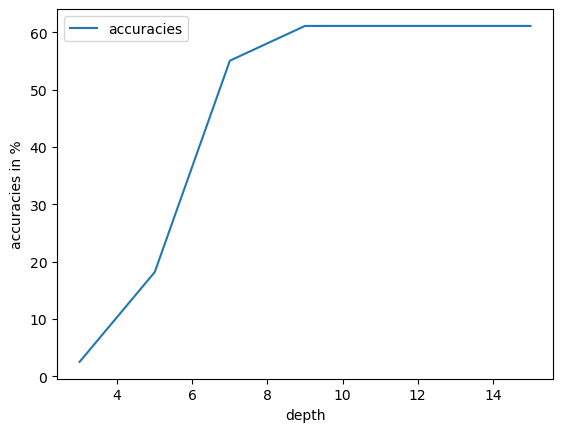

In [50]:
from matplotlib import pyplot as plt

depths = np.arange(3, 17, 2)
plt.plot(depths, accuracies, label='accuracies')
plt.xlabel('depth')
plt.ylabel('accuracies in %')
plt.legend()
plt.show()

### Skelearn DecisionTreeClassifier

In [51]:
from sklearn.tree import DecisionTreeClassifier

start = time.time()
dt_fast = DecisionTreeClassifier(max_depth=None, random_state=123)
dt_fast.fit(X_train, y_train)
end = time.time()

predictions = dt_fast.predict(X_valid)
accuracy = np.mean(predictions == y_valid) * 100
accuracy, end - start

(np.float64(62.62626262626263), 0.27667880058288574)

### Sklearn RandomForestClassifer

In [55]:
from sklearn.ensemble import RandomForestClassifier

start = time.time()
dt_fast = RandomForestClassifier(n_estimators=10, random_state=123, max_depth=None)
dt_fast.fit(X_train, y_train)
end = time.time()

predictions = dt_fast.predict(X_valid)
accuracy = np.mean(predictions == y_valid) * 100
accuracy, end - start

(np.float64(85.85858585858585), 0.1186068058013916)

### Doing the same using XGBoost

In [43]:
from xgboost import XGBClassifier

start = time.time()
xgb = XGBClassifier(max_depth=None, random_state=123).fit(X_train, y_train)
end = time.time()
xgb_predictions = xgb.predict(X_valid)
accuracy = np.mean(xgb_predictions==y_valid)*100
accuracy, end - start

(np.float64(87.37373737373737), 2.8162782192230225)

### Implementing Random Forest for Better performance

In [35]:
class RandomForest:
    def __init__(self, num_trees=10, max_depth=4, min_samples_split=2):
         self.trees = []
         self.num_trees = num_trees
         self.max_depth = max_depth
         self.min_samples_split = min_samples_split

    def fit(self, X, y):
        n_rows, n_features = X.shape

        for i in range(self.num_trees):
            dt = DecisionTree(max_depth=self.max_depth, min_samples_split=self.min_samples_split)
            np.random.seed(123 + i)

            # Choose a random subset with replacement
            idxs = np.random.choice(n_rows, n_rows, replace=True)
    
            # Choosing a random set of features to train on
            features = np.random.choice(n_features, int(0.7*n_features), replace=False)

            # Training and adding this model to our arsenal
            X_sample, y_sample = X[idxs][:, features], y[idxs]
            dt.fit(X_sample, y_sample)
            self.trees.append((dt, features))

            print(f"{i} th iteration is done")

    def predict(self, X):

        all_predictions = np.array([dt.predict(X[:, features]) for dt, features in self.trees])

        all_predictions = all_predictions.T

        final_predictions = []

        for row in all_predictions:
            classes, counts = np.unique(row, return_counts=True)
            final_predictions.append(classes[np.argmax(counts)])

        return np.array(final_predictions)
        

In [56]:
start = time.time()
rf = RandomForest(num_trees=20, max_depth=float('inf'))
rf.fit(X_train, y_train)
end = time.time()
end - start

0 th iteration is done
1 th iteration is done
2 th iteration is done
3 th iteration is done
4 th iteration is done
5 th iteration is done
6 th iteration is done
7 th iteration is done
8 th iteration is done
9 th iteration is done
10 th iteration is done
11 th iteration is done
12 th iteration is done
13 th iteration is done
14 th iteration is done
15 th iteration is done
16 th iteration is done
17 th iteration is done
18 th iteration is done
19 th iteration is done


27.93553900718689

In [57]:
np.mean(rf.predict(X_valid) == y_valid)*100

np.float64(90.9090909090909)

### Final Result

|Model| Accuracy(\%) | Time to Train(s)
|--|--|--|
| Simple Scratch Decision Tree | 62.12 | 2.35
| sklearn DecisionTreeClassifier | 62.62 | 0.26
| xgboost XGBClassifier | 87.37 | 2.81
| sklearn RandomForestClassifier | 97.4747 | 0.81 
| Simple Scratch Random Forest  | 85.859 | 13